# Ejercicio 1: Iteración de Valores en un Grid

## Pregunta del ejercicio

¿Cómo puede un agente encontrar la mejor ruta desde un punto de inicio hasta una meta en un grid de 15 x 15, evitando obstáculos y minimizando el costo de sus movimientos?

## ¿Qué busca solucionar?

El código busca resolver un problema de toma de decisiones. Para cada posición del grid, calcula qué tan conveniente es estar allí y determina cuál movimiento permite acercarse a la meta con el mayor beneficio esperado.

El agente debe:

- Llegar al estado final (`F`).
- Evitar los cinco obstáculos (`#`).
- Pagar un costo por cada movimiento.
- Elegir la mejor acción desde cualquier posición del grid.

## Temas involucrados

- Inteligencia artificial.
- Aprendizaje por refuerzo.
- Procesos de decisión de Markov.
- Iteración de valores (*Value Iteration*).
- Ecuación de Bellman.
- Función de valor `V(s)`.
- Extracción de políticas (*Policy Extraction*).
- Recompensas, penalizaciones y costo de movimiento.
- Exploración de estados y selección de acciones.
- Visualización mediante mapas de calor.

Calculando los valores de los estados (Iteración de valores)...
Convergencia alcanzada en 29 iteraciones.

Política Óptima (Direcciones hacia la meta):
↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓
↓ ↓ ↓ → ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓
↓ ↓ ↓ # ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓
↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓
↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ → ↓ ↓ ↓ ↓ ↓ ↓
↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ # ↓ ↓ ↓ ↓ ↓ ↓
↓ ↓ ↓ ↓ ↓ ↓ → ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓
↓ ↓ ↓ ↓ ↓ ↓ # ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓
↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓
↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ → ↓ ↓ ↓
↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ # ↓ ↓ ↓
↓ ↓ ↓ ↓ → ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓
↓ ↓ ↓ ↓ # ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓
↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓
→ → → → → → → → → → → → → → F


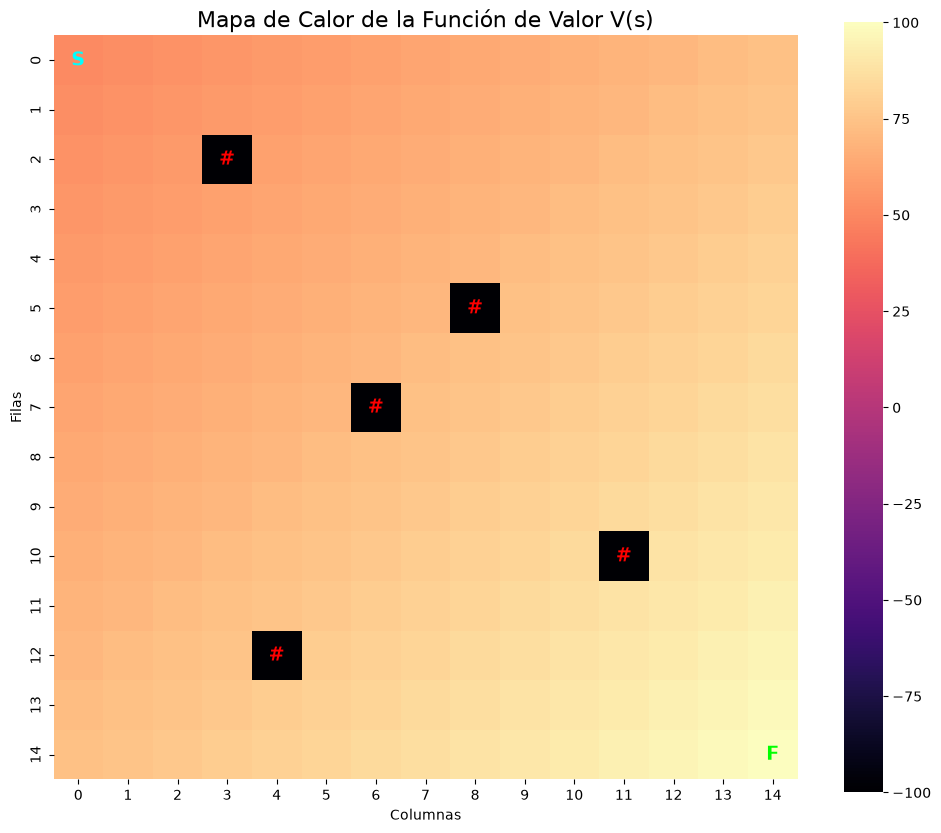

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Parámetros del Entorno de RL
# ==========================================
gamma = 0.99  # Factor de descuento (importancia de recompensas futuras)
theta = 1e-4  # Umbral de convergencia
recompensa_meta = 100
penalizacion_obstaculo = -100
costo_paso = -1

# Definición de acciones: (delta_fila, delta_columna)
acciones = {
    "↑": (-1, 0),
    "↓": (1, 0),
    "←": (0, -1),
    "→": (0, 1)
}

# ==========================================
# 2. Iteración de Valores (Value Iteration)
# ==========================================
valores = np.zeros((filas, columnas))

# Establecer valores fijos para estados terminales
valores[final[0], final[1]] = recompensa_meta
for r, c in obstaculos:
    valores[r, c] = penalizacion_obstaculo

print("Calculando los valores de los estados (Iteración de valores)...")
iteracion = 0
while True:
    delta = 0
    nuevos_valores = np.copy(valores)
    
    for i in range(filas):
        for j in range(columnas):
            # No actualizar la meta ni los obstáculos
            if (i, j) == final or (i, j) in obstaculos:
                continue
                
            v_max = -float('inf')
            
            # Evaluar todas las acciones posibles desde el estado (i,j)
            for accion, (di, dj) in acciones.items():
                ni, nj = i + di, j + dj
                
                # Verificar si el movimiento está dentro del grid
                if 0 <= ni < filas and 0 <= nj < columnas:
                    v_siguiente = valores[ni, nj]
                else:
                    # Si choca con el borde, se queda en el mismo lugar
                    v_siguiente = valores[i, j]
                
                # Ecuación de Bellman
                v_accion = costo_paso + gamma * v_siguiente
                
                if v_accion > v_max:
                    v_max = v_accion
                    
            nuevos_valores[i, j] = v_max
            delta = max(delta, abs(v_max - valores[i, j]))
            
    valores = nuevos_valores
    iteracion += 1
    
    if delta < theta:
        break

print(f"Convergencia alcanzada en {iteracion} iteraciones.\n")

# ==========================================
# 3. Extracción de Políticas (Policy Extraction)
# ==========================================
politica = [[" " for _ in range(columnas)] for _ in range(filas)]

for i in range(filas):
    for j in range(columnas):
        if (i, j) == final:
            politica[i][j] = "F"
            continue
        if (i, j) in obstaculos:
            politica[i][j] = "#"
            continue
            
        v_max = -float('inf')
        mejor_accion = ""
        
        for accion, (di, dj) in acciones.items():
            ni, nj = i + di, j + dj
            if 0 <= ni < filas and 0 <= nj < columnas:
                v_siguiente = valores[ni, nj]
            else:
                v_siguiente = valores[i, j]
                
            v_accion = costo_paso + gamma * v_siguiente
            
            if v_accion > v_max:
                v_max = v_accion
                mejor_accion = accion
                
        politica[i][j] = mejor_accion

# Imprimir la política en consola
print("Política Óptima (Direcciones hacia la meta):")
for fila in politica:
    print(" ".join(fila))

# ==========================================
# 4. Visualización con Mapa de Calor
# ==========================================
plt.figure(figsize=(12, 10))
# Usamos una máscara para que los obstáculos resalten de manera distinta si lo deseamos,
# pero en este caso el colormap lo mostrará en colores fríos debido al valor de -100.
sns.heatmap(valores, annot=False, cmap="magma", cbar=True, square=True)

# Añadir anotaciones para Inicio (S), Meta (F) y Obstáculos (#)
plt.text(inicio[1] + 0.5, inicio[0] + 0.5, 'S', color='cyan', ha='center', va='center', fontsize=14, fontweight='bold')
plt.text(final[1] + 0.5, final[0] + 0.5, 'F', color='lime', ha='center', va='center', fontsize=14, fontweight='bold')

for r, c in obstaculos:
    plt.text(c + 0.5, r + 0.5, '#', color='red', ha='center', va='center', fontsize=14, fontweight='bold')

plt.title("Mapa de Calor de la Función de Valor V(s)", fontsize=16)
plt.xlabel("Columnas")
plt.ylabel("Filas")
plt.show()